# Cantera Integration for Thermodynamic and Kinetic Data

This notebook demonstrates how to use Cantera mechanism files with difflow:

1. **Simple Example**: Import species data for ideal thermodynamics
2. **Intermediate Example**: Import critical properties for equations of state
3. **Advanced Example**: PFR with pressure drop using Cantera kinetics
4. **Limitations and Best Practices**

## Why Use Cantera Data?

- **Validated databases**: NASA polynomials, GRI-Mech, and other validated mechanisms
- **Extensive species coverage**: Thousands of species available
- **Consistent thermodynamics**: Ensures thermodynamic consistency (Gibbs-Helmholtz)
- **Community standard**: Widely used in combustion and chemical kinetics

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

# Enable float64 for better precision
jax.config.update('jax_enable_x64', True)

from difflow import (
    make_stream,
    IdealThermo,
    PengRobinson,
    GasPFR, GasPFRParams,
)

from difflow.cantera_import import (
    import_species_data,
    import_critical_props,
    import_reactions,
    load_mechanism,
    list_available_species,
    list_available_reactions,
)

## 1. Simple Example: Importing Species Data

We'll use a test mechanism file included with difflow. In practice, you'd use standard Cantera mechanisms like `gri30.yaml`.

In [2]:
# Path to test mechanism (included with difflow tests)
MECHANISM_FILE = '../tests/data/test_mechanism.yaml'

# List available species
available = list_available_species(MECHANISM_FILE)
print("Available species:")
print(available)

Available species:
['CH4', 'O2', 'CO2', 'H2O', 'N2', 'CO', 'H2']


In [3]:
# Import specific species for combustion
combustion_species = ['CH4', 'O2', 'CO2', 'H2O', 'N2']
species_data = import_species_data(MECHANISM_FILE, combustion_species)

print("\nImported species data:")
for name, data in species_data.items():
    print(f"  {name}: MW={data.MW:.2f} g/mol, Hf={data.Hf/1000:.1f} kJ/mol")


Imported species data:
  CH4: MW=16.04 g/mol, Hf=-74.6 kJ/mol
  O2: MW=32.00 g/mol, Hf=0.0 kJ/mol
  CO2: MW=44.01 g/mol, Hf=-393.5 kJ/mol
  H2O: MW=18.02 g/mol, Hf=-241.8 kJ/mol
  N2: MW=28.01 g/mol, Hf=0.0 kJ/mol


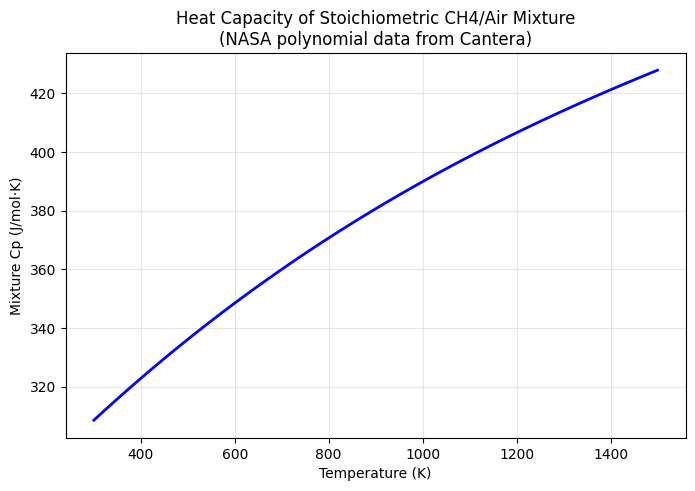

In [4]:
# Create IdealThermo object from imported data
thermo = IdealThermo(species_data)

# Calculate mixture Cp at different temperatures
# Stoichiometric CH4/air mixture
composition = {
    'CH4': jnp.array(1.0),
    'O2': jnp.array(2.0),
    'CO2': jnp.array(0.0),
    'H2O': jnp.array(0.0),
    'N2': jnp.array(7.52),  # Air is ~79% N2
}

T_range = jnp.linspace(300, 1500, 50)
Cp_values = [float(thermo.Cp_mix(composition, T)) for T in T_range]

plt.figure(figsize=(8, 5))
plt.plot(T_range, Cp_values, 'b-', linewidth=2)
plt.xlabel('Temperature (K)')
plt.ylabel('Mixture Cp (J/mol·K)')
plt.title('Heat Capacity of Stoichiometric CH4/Air Mixture\n(NASA polynomial data from Cantera)')
plt.grid(True, alpha=0.3)
plt.show()

## 2. Intermediate Example: Equations of State

Import critical properties for use with Peng-Robinson or SRK equations of state.

In [5]:
# Import critical properties
critical_props = import_critical_props(MECHANISM_FILE, ['CH4', 'CO2', 'N2', 'O2'])

print("Critical properties:")
for name, props in critical_props.items():
    print(f"  {name}: Tc={props.Tc:.1f} K, Pc={props.Pc/1e6:.2f} MPa, ω={props.omega:.3f}")

Critical properties:
  CH4: Tc=190.6 K, Pc=4.60 MPa, ω=0.011
  O2: Tc=154.6 K, Pc=5.04 MPa, ω=0.022
  CO2: Tc=304.2 K, Pc=7.38 MPa, ω=0.228
  N2: Tc=126.2 K, Pc=3.39 MPa, ω=0.039


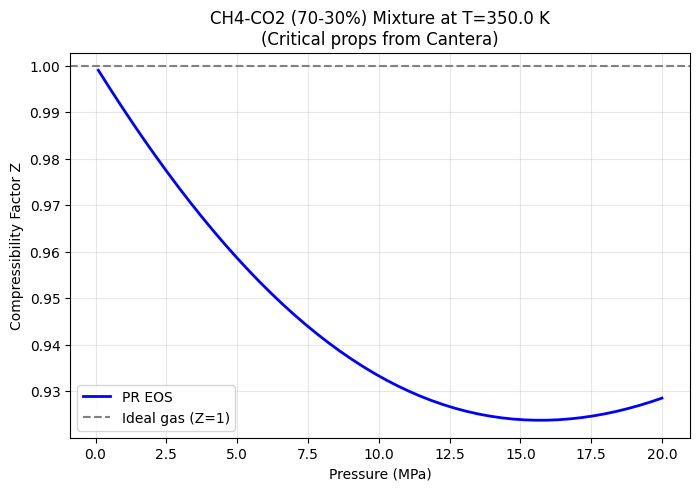

In [6]:
# Create Peng-Robinson EOS
eos = PengRobinson(critical_props)

# Calculate compressibility factor for CH4-CO2 mixture at various pressures
T = jnp.array(350.0)  # K
y = jnp.array([0.7, 0.3, 0.0, 0.0])  # 70% CH4, 30% CO2

P_range = jnp.linspace(0.1e6, 20e6, 50)  # 0.1 to 20 MPa
Z_values = [float(eos.solve_Z(T, P, y, phase='vapor')) for P in P_range]

plt.figure(figsize=(8, 5))
plt.plot(P_range/1e6, Z_values, 'b-', linewidth=2, label='PR EOS')
plt.axhline(y=1.0, color='gray', linestyle='--', label='Ideal gas (Z=1)')
plt.xlabel('Pressure (MPa)')
plt.ylabel('Compressibility Factor Z')
plt.title(f'CH4-CO2 (70-30%) Mixture at T={float(T)} K\n(Critical props from Cantera)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3. Importing Reaction Kinetics

Extract Arrhenius parameters from mechanism files.

In [7]:
# List available reactions
equations = list_available_reactions(MECHANISM_FILE)
print("Available reactions:")
for i, eq in enumerate(equations):
    print(f"  {i}: {eq}")

Available reactions:
  0: CH4 + 2 O2 <=> CO2 + 2 H2O
  1: 2 CO + O2 <=> 2 CO2
  2: 2 H2 + O2 <=> 2 H2O
  3: CH4 + H2O <=> CO + 3 H2


In [8]:
# Import reaction data
reactions = import_reactions(MECHANISM_FILE)

print("\nReaction kinetics:")
for rxn in reactions:
    rate = rxn['rate_params']
    print(f"\n{rxn['equation']}")
    print(f"  A = {rate['A']:.2e}")
    print(f"  n = {rate['n']:.1f}")
    print(f"  Ea = {rate['Ea']/1000:.1f} kJ/mol")
    print(f"  Reactants: {rxn['reactants']}")
    print(f"  Products: {rxn['products']}")


Reaction kinetics:

CH4 + 2 O2 <=> CO2 + 2 H2O
  A = 1.00e+13
  n = 0.0
  Ea = 200.0 kJ/mol
  Reactants: {'CH4': 1.0, 'O2': 2.0}
  Products: {'CO2': 1.0, 'H2O': 2.0}

2 CO + O2 <=> 2 CO2
  A = 2.50e+12
  n = 0.0
  Ea = 167.4 kJ/mol
  Reactants: {'CO': 2.0, 'O2': 1.0}
  Products: {'CO2': 2.0}

2 H2 + O2 <=> 2 H2O
  A = 1.00e+14
  n = 0.0
  Ea = 150.0 kJ/mol
  Reactants: {'H2': 2.0, 'O2': 1.0}
  Products: {'H2O': 2.0}

CH4 + H2O <=> CO + 3 H2
  A = 3.00e+11
  n = 0.5
  Ea = 125.5 kJ/mol
  Reactants: {'CH4': 1.0, 'H2O': 1.0}
  Products: {'CO': 1.0, 'H2': 3.0}


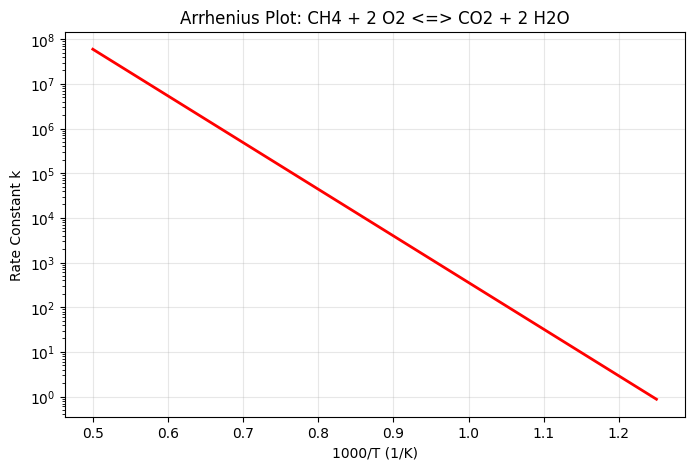

In [9]:
# Plot rate constant vs temperature for methane combustion
ch4_rxn = reactions[0]  # CH4 + 2 O2 <=> CO2 + 2 H2O
A = ch4_rxn['rate_params']['A']
Ea = ch4_rxn['rate_params']['Ea']
n = ch4_rxn['rate_params']['n']

R = 8.314  # J/(mol·K)
T_range = jnp.linspace(800, 2000, 100)
k_values = A * (T_range ** n) * jnp.exp(-Ea / (R * T_range))

plt.figure(figsize=(8, 5))
plt.semilogy(1000/T_range, k_values, 'r-', linewidth=2)
plt.xlabel('1000/T (1/K)')
plt.ylabel('Rate Constant k')
plt.title(f'Arrhenius Plot: {ch4_rxn["equation"]}')
plt.grid(True, alpha=0.3)
plt.show()

## 4. Advanced Example: Gas-Phase PFR with Pressure Drop

A more realistic example: Steam methane reforming (SMR) in a packed bed reactor.

**Reaction**: CH4 + H2O → CO + 3H2 (endothermic, mole change)

Features:
- Uses Cantera kinetic data
- Pressure drop via Ergun equation
- Variable volumetric flow due to mole change
- Fully differentiable for optimization

In [10]:
# Get SMR reaction kinetics from mechanism
smr_rxn = reactions[3]  # CH4 + H2O <=> CO + 3 H2
print(f"Steam Methane Reforming: {smr_rxn['equation']}")
print(f"  A = {smr_rxn['rate_params']['A']:.2e}")
print(f"  Ea = {smr_rxn['rate_params']['Ea']/1000:.1f} kJ/mol")

# Build stoichiometry matrix for: CH4, H2O, CO, H2, N2 (inert)
# CH4 + H2O -> CO + 3H2
stoich = jnp.array([[-1.0], [-1.0], [1.0], [3.0], [0.0]])

print(f"\nStoichiometry (species order: CH4, H2O, CO, H2, N2):")
print(stoich.T)

Steam Methane Reforming: CH4 + H2O <=> CO + 3 H2
  A = 3.00e+11
  Ea = 125.5 kJ/mol

Stoichiometry (species order: CH4, H2O, CO, H2, N2):
[[-1. -1.  1.  3.  0.]]


In [11]:
# Import species data for SMR
smr_species = ['CH4', 'H2O', 'CO', 'H2', 'N2']
smr_data = import_species_data(MECHANISM_FILE, smr_species)

# Create thermo
smr_thermo = IdealThermo(smr_data)

In [12]:
# Define rate function using Cantera kinetics
# Note: The test mechanism has very fast kinetics (A=3e11) that make the ODE stiff.
# We scale down the pre-exponential factor for numerical stability in this demo.
A_smr = smr_rxn['rate_params']['A'] * 1e-8  # Scale down for stability
Ea_smr = smr_rxn['rate_params']['Ea']
n_smr = smr_rxn['rate_params']['n']

print(f"Original A from mechanism: {smr_rxn['rate_params']['A']:.2e}")
print(f"Scaled A for demo: {A_smr:.2e}")

def smr_rate(C, T, params):
    """Steam methane reforming rate law.
    
    Simplified power-law kinetics (in reality, Langmuir-Hinshelwood is more accurate).
    r = k * C_CH4 * C_H2O
    """
    k = params['A'] * (T ** params['n']) * jnp.exp(-params['Ea'] / (8.314 * T))
    return jnp.array([k * C['CH4'] * C['H2O']])

rate_params = {
    'A': jnp.array(A_smr),
    'Ea': jnp.array(Ea_smr),
    'n': jnp.array(n_smr),
}

Original A from mechanism: 3.00e+11
Scaled A for demo: 3.00e+03


In [13]:
# Create Gas-Phase PFR with pressure drop
pfr_params = GasPFRParams(
    V=jnp.array(0.5),  # Reactor volume (m³)
    rate_fn=smr_rate,
    stoich=stoich,
    rate_params=rate_params,
    species_order=['CH4', 'H2O', 'CO', 'H2', 'N2'],
    n_save_points=201,
    alpha=jnp.array(2000.0),  # Pressure drop parameter (Pa/m³) - moderate drop
)

pfr = GasPFR(pfr_params, thermo=smr_thermo, mode='isothermal')

In [14]:
# Create feed stream: 3:1 steam-to-carbon ratio, 20 bar
P_inlet = 20e5  # 20 bar
T_reaction = 1100.0  # K (typical SMR temperature)

feed = make_stream(
    {'CH4': 1.0, 'H2O': 3.0, 'CO': 0.0, 'H2': 0.0, 'N2': 0.1},  # mol/s
    T=T_reaction,
    P=P_inlet,
)

print("Feed conditions:")
print(f"  Temperature: {T_reaction} K")
print(f"  Pressure: {P_inlet/1e5:.1f} bar")
print(f"  Steam/Carbon: 3.0")

Feed conditions:
  Temperature: 1100.0 K
  Pressure: 20.0 bar
  Steam/Carbon: 3.0


In [15]:
# Run PFR simulation
outlet, info = pfr(feed, T_spec=T_reaction)

print("\nReactor Performance:")
print(f"  CH4 conversion: {float(info['conversion']['CH4'])*100:.1f}%")
print(f"  Pressure drop: {float(info['pressure_drop'])/1e5:.2f} bar")
print(f"  Exit pressure: {float(outlet['P'])/1e5:.1f} bar")

print("\nOutlet flows (mol/s):")
for sp in ['CH4', 'H2O', 'CO', 'H2']:
    print(f"  {sp}: {float(outlet[f'F_{sp}']):.3f}")


Reactor Performance:
  CH4 conversion: 100.0%
  Pressure drop: 0.01 bar
  Exit pressure: 20.0 bar

Outlet flows (mol/s):
  CH4: 0.000
  H2O: 2.000
  CO: 1.000
  H2: 3.000


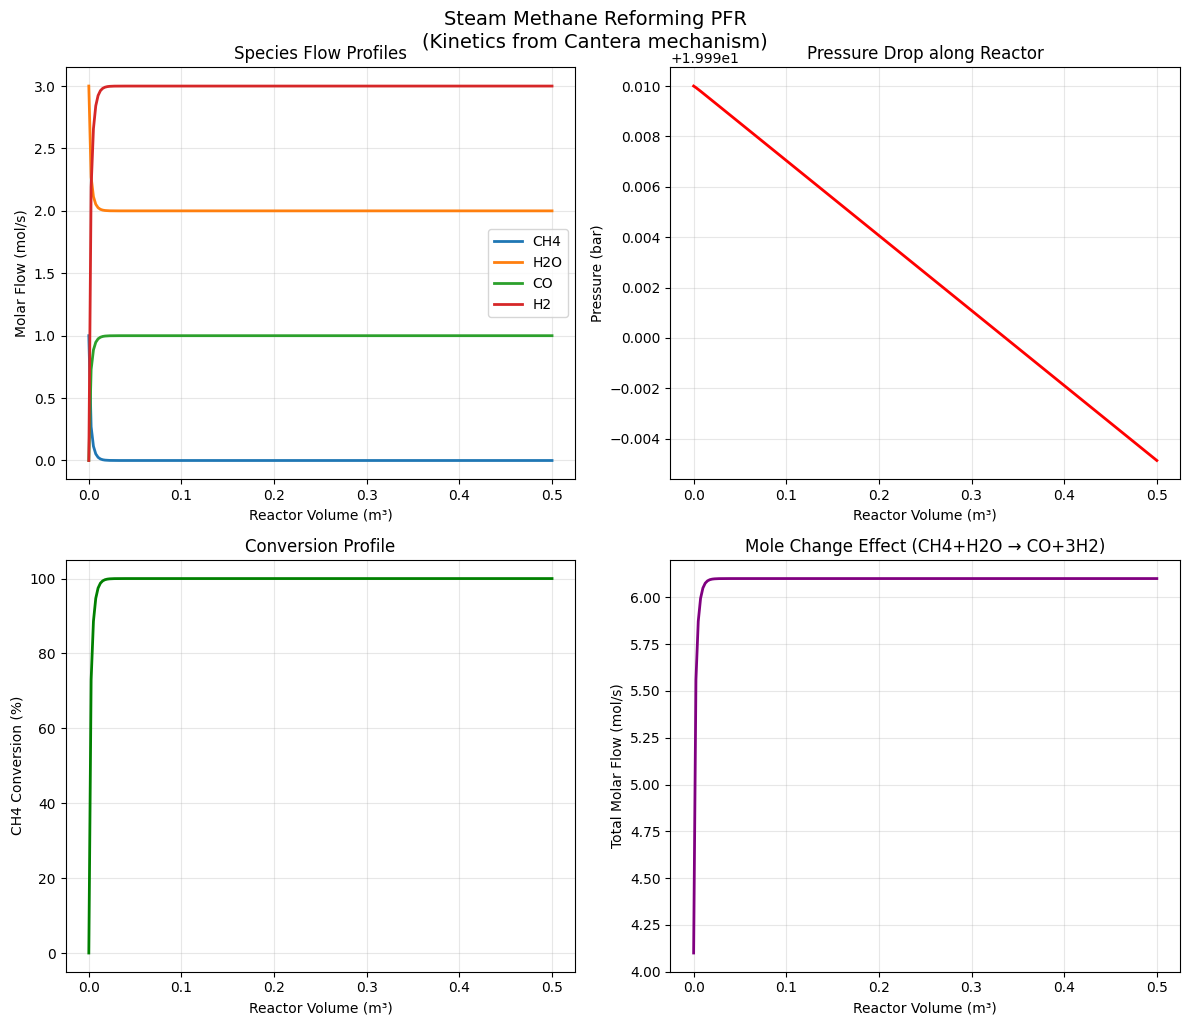

In [16]:
# Plot profiles along reactor
profiles = info['profiles']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Flow profiles
ax1 = axes[0, 0]
V = profiles['V']
for i, sp in enumerate(['CH4', 'H2O', 'CO', 'H2']):
    ax1.plot(V, profiles['F'][:, i], label=sp, linewidth=2)
ax1.set_xlabel('Reactor Volume (m³)')
ax1.set_ylabel('Molar Flow (mol/s)')
ax1.set_title('Species Flow Profiles')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Pressure profile
ax2 = axes[0, 1]
ax2.plot(V, profiles['P']/1e5, 'r-', linewidth=2)
ax2.set_xlabel('Reactor Volume (m³)')
ax2.set_ylabel('Pressure (bar)')
ax2.set_title('Pressure Drop along Reactor')
ax2.grid(True, alpha=0.3)

# Conversion profile
ax3 = axes[1, 0]
F_CH4_in = float(feed['F_CH4'])
conversion = (F_CH4_in - profiles['F'][:, 0]) / F_CH4_in
ax3.plot(V, conversion * 100, 'g-', linewidth=2)
ax3.set_xlabel('Reactor Volume (m³)')
ax3.set_ylabel('CH4 Conversion (%)')
ax3.set_title('Conversion Profile')
ax3.grid(True, alpha=0.3)

# Mole change effect
ax4 = axes[1, 1]
total_moles = jnp.sum(profiles['F'], axis=1)
ax4.plot(V, total_moles, 'purple', linewidth=2)
ax4.set_xlabel('Reactor Volume (m³)')
ax4.set_ylabel('Total Molar Flow (mol/s)')
ax4.set_title('Mole Change Effect (CH4+H2O → CO+3H2)')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Steam Methane Reforming PFR\n(Kinetics from Cantera mechanism)', 
             y=1.02, fontsize=14)
plt.show()

## 5. Gradient-Based Optimization

Optimize reactor volume to maximize H2 production while minimizing pressure drop.

In [17]:
def objective(V):
    """Objective: maximize H2 production, penalize pressure drop."""
    params = GasPFRParams(
        V=V,
        rate_fn=smr_rate,
        stoich=stoich,
        rate_params=rate_params,
        species_order=['CH4', 'H2O', 'CO', 'H2', 'N2'],
        n_save_points=101,
        alpha=jnp.array(50000.0),  # Higher pressure drop for interesting trade-off
    )
    pfr = GasPFR(params, thermo=smr_thermo, mode='isothermal')
    outlet, info = pfr(feed, T_spec=T_reaction)
    
    H2_production = outlet['F_H2']
    pressure_drop_penalty = 0.5 * info['pressure_drop'] / 1e5  # Stronger penalty per bar
    
    # Maximize H2 = minimize negative H2
    return -H2_production + pressure_drop_penalty

# Compute gradient
grad_obj = jax.grad(objective)

# Simple gradient descent
# Start with a small reactor to see convergence
V = jnp.array(0.005)  # Initial volume - very small to show convergence
lr = 0.001
history = []

print("Gradient descent optimization:")
print("-" * 50)

for i in range(100):
    obj_val = float(objective(V))
    g = grad_obj(V)
    V = V - lr * g
    V = jnp.clip(V, 0.001, 0.1)  # Bounds: 0.001 to 0.1 m³
    history.append({'V': float(V), 'obj': obj_val, 'grad': float(g)})
    
    if (i+1) % 20 == 0:
        print(f"  Iter {i+1:2d}: V = {float(V):.4f} m³, H2 ~ {-obj_val:.2f} mol/s")
    
    if abs(float(g)) < 0.001:  # Convergence criterion
        print(f"\nConverged at iteration {i+1}")
        break

print(f"\nOptimal reactor volume: {float(V):.4f} m³")

# Evaluate at optimum
opt_params = GasPFRParams(
    V=V,
    rate_fn=smr_rate,
    stoich=stoich,
    rate_params=rate_params,
    species_order=['CH4', 'H2O', 'CO', 'H2', 'N2'],
    n_save_points=101,
    alpha=jnp.array(50000.0),
)
opt_pfr = GasPFR(opt_params, thermo=smr_thermo, mode='isothermal')
opt_outlet, opt_info = opt_pfr(feed, T_spec=T_reaction)

print(f"H2 production: {float(opt_outlet['F_H2']):.3f} mol/s")
print(f"CH4 conversion: {float(opt_info['conversion']['CH4'])*100:.1f}%")
print(f"Pressure drop: {float(opt_info['pressure_drop'])/1e5:.2f} bar")

Gradient descent optimization:
--------------------------------------------------


  Iter 20: V = 0.0929 m³, H2 ~ 2.97 mol/s


  Iter 40: V = 0.0854 m³, H2 ~ 2.97 mol/s


  Iter 60: V = 0.0780 m³, H2 ~ 2.97 mol/s


  Iter 80: V = 0.0705 m³, H2 ~ 2.97 mol/s


  Iter 100: V = 0.0631 m³, H2 ~ 2.98 mol/s

Optimal reactor volume: 0.0631 m³


H2 production: 3.000 mol/s
CH4 conversion: 100.0%
Pressure drop: 0.05 bar


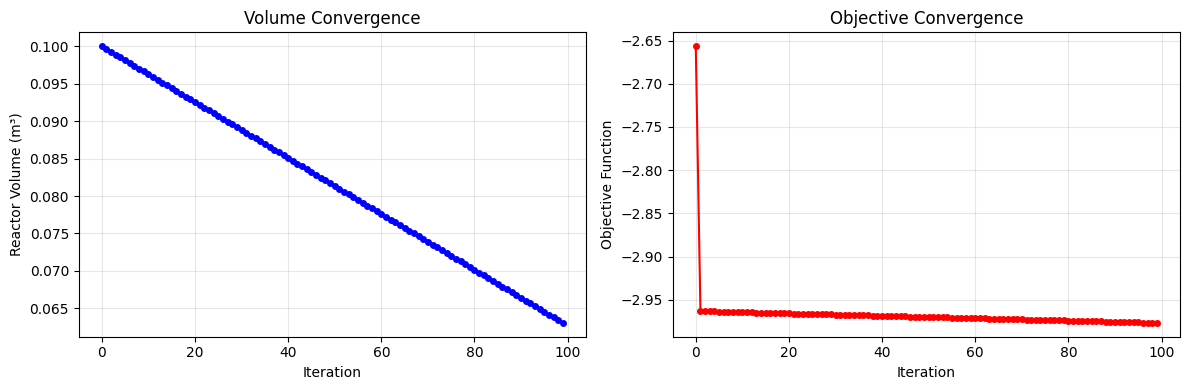

In [18]:
# Plot optimization convergence
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot([h['V'] for h in history], 'b-o', markersize=4)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Reactor Volume (m³)')
axes[0].set_title('Volume Convergence')
axes[0].grid(True, alpha=0.3)

axes[1].plot([h['obj'] for h in history], 'r-o', markersize=4)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Objective Function')
axes[1].set_title('Objective Convergence')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Limitations and Best Practices

### Limitations

1. **NASA Polynomial Approximation**: 
   - Cantera uses NASA7 (7 coefficients) or NASA9 (9 coefficients)
   - difflow uses 4th-order polynomials for Cp
   - High-temperature accuracy may be reduced (typically <1% error below 2000 K)

2. **Temperature Range**:
   - NASA polynomials have specific valid ranges (e.g., 300-1000 K, 1000-5000 K)
   - difflow import uses high-T coefficients by default
   - Extrapolation outside range can cause errors

3. **Antoine/Hvap Estimation**:
   - Cantera gas-phase mechanisms don't include vapor pressure data
   - Antoine and Hvap coefficients are estimated from boiling points
   - For VLE applications, use difflow's built-in database or manual data

4. **Complex Kinetics**:
   - Only elementary Arrhenius kinetics are imported directly
   - Pressure-dependent reactions (Troe, PLOG) need manual handling
   - Third-body efficiencies are not automatically imported

### Best Practices

1. **Validate Against Cantera**:
   ```python
   # Compare Cp values at key temperatures
   import cantera as ct
   gas = ct.Solution('gri30.yaml')
   gas.TPX = 500, 101325, 'CH4:1'
   print(f"Cantera Cp: {gas.cp_mole}")
   print(f"difflow Cp: {thermo.Cp_species('CH4', 500)}")
   ```

2. **Use Built-in Database for VLE**:
   - For flash calculations, prefer `difflow.database` over Cantera import
   - Cantera excels at gas-phase kinetics, not phase equilibrium

3. **Check Temperature Ranges**:
   - Print temperature ranges during import
   - Stay within valid range for best accuracy

4. **Kinetics Validation**:
   - Compare rate constants at reference temperature
   - Verify reaction orders match expected mechanism

In [19]:
# Demonstrate temperature range checking
print("Checking imported data quality:")
print("="*50)

for name, data in smr_data.items():
    # Calculate Cp at several temperatures
    T_test = [300, 500, 1000, 1500]
    Cp_vals = [data.Cp_coeffs[0] + data.Cp_coeffs[1]*T + 
               data.Cp_coeffs[2]*T**2 + data.Cp_coeffs[3]*T**3 
               for T in T_test]
    
    print(f"\n{name}:")
    print(f"  MW = {data.MW:.2f} g/mol")
    print(f"  Hf = {data.Hf/1000:.1f} kJ/mol")
    print(f"  Cp (J/mol·K):")
    for T, Cp in zip(T_test, Cp_vals):
        # Flag unusual values
        flag = " ⚠️" if Cp < 20 or Cp > 100 else ""
        print(f"    T={T}K: Cp={Cp:.1f}{flag}")

Checking imported data quality:

CH4:
  MW = 16.04 g/mol
  Hf = -74.6 kJ/mol
  Cp (J/mol·K):
    T=300K: Cp=36.4
    T=500K: Cp=49.1
    T=1000K: Cp=74.0
    T=1500K: Cp=91.8

H2O:
  MW = 18.02 g/mol
  Hf = -241.8 kJ/mol
  Cp (J/mol·K):
    T=300K: Cp=29.1
    T=500K: Cp=33.1
    T=1000K: Cp=41.3
    T=1500K: Cp=47.5

N2:
  MW = 28.01 g/mol
  Hf = 0.0 kJ/mol
  Cp (J/mol·K):
    T=300K: Cp=27.7
    T=500K: Cp=29.4
    T=1000K: Cp=32.7
    T=1500K: Cp=35.0

CO:
  MW = 28.01 g/mol
  Hf = -110.5 kJ/mol
  Cp (J/mol·K):
    T=300K: Cp=28.4
    T=500K: Cp=30.0
    T=1000K: Cp=33.2
    T=1500K: Cp=35.3

H2:
  MW = 2.02 g/mol
  Hf = 0.0 kJ/mol
  Cp (J/mol·K):
    T=300K: Cp=26.3
    T=500K: Cp=27.5
    T=1000K: Cp=30.2
    T=1500K: Cp=32.4


## Summary

This notebook demonstrated:

1. **Species Data Import**: NASA polynomial thermodynamic data → difflow `SpeciesData`
2. **Critical Properties**: Extract Tc, Pc, ω for Peng-Robinson/SRK equations of state
3. **Reaction Kinetics**: Arrhenius parameters (A, Ea, n) for rate expressions
4. **Advanced Application**: Gas-phase PFR with pressure drop using Cantera kinetics
5. **Optimization**: Gradient-based reactor design using JAX autodiff
6. **Limitations**: Temperature ranges, polynomial approximations, missing VLE data

### Key Functions

| Function | Description |
|----------|-------------|
| `import_species_data()` | Load species thermodynamic data |
| `import_critical_props()` | Load critical properties for EOS |
| `import_reactions()` | Load reaction mechanisms with kinetics |
| `load_mechanism()` | Load complete mechanism (species + reactions) |
| `list_available_species()` | List species in mechanism file |
| `list_available_reactions()` | List reactions in mechanism file |